<a href="https://colab.research.google.com/github/radhiikhanapurkar18/task-1-titanic-survival-prediction-/blob/main/Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/dataset/Titanic-Dataset.csv'
df = pd.read_csv(file_path)
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print(f"Original shape: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"New shape after removing duplicates: {df.shape}")

Original shape: (891, 12)
New shape after removing duplicates: (891, 12)


In [ ]:
print(f"Shape before removing duplicate columns: {df.shape}")

df = df.T.drop_duplicates().T

print(f"Shape after removing duplicate columns: {df.shape}")

Shape before removing duplicate columns: (891, 12)
Shape after removing duplicate columns: (891, 12)


In [ ]:
numerical_cols = df.select_dtypes(include=['number']).columns

print("Mean of numerical columns:")
print(df[numerical_cols].mean())

print("\nMedian of numerical columns:")
print(df[numerical_cols].median())

Mean of numerical columns:
Series([], dtype: float64)

Median of numerical columns:
Series([], dtype: float64)


In [ ]:
print(df.dtypes)

PassengerId    object
Survived       object
Pclass         object
Name           object
Sex            object
Age            object
SibSp          object
Parch          object
Ticket         object
Fare           object
Cabin          object
Embarked       object
dtype: object


In [ ]:
numerical_columns_to_convert = ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

for col in numerical_columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [ ]:
numerical_cols = df.select_dtypes(include=['number']).columns

print("Mean of numerical columns:")
print(df[numerical_cols].mean())

print("\nMedian of numerical columns:")
print(df[numerical_cols].median())

Mean of numerical columns:
PassengerId    446.000000
Survived         0.383838
Pclass           2.308642
Age             29.699118
SibSp            0.523008
Parch            0.381594
Fare            32.204208
dtype: float64

Median of numerical columns:
PassengerId    446.0000
Survived         0.0000
Pclass           3.0000
Age             28.0000
SibSp            0.0000
Parch            0.0000
Fare            14.4542
dtype: float64


In [ ]:
numerical_cols = df.select_dtypes(include=['number']).columns
absolute_correlation_matrix = df[numerical_cols].corr().abs()

print("Absolute Correlation Matrix:")
display(absolute_correlation_matrix)

Absolute Correlation Matrix:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,0.005007,0.035144,0.036847,0.057527,0.001652,0.012658
Survived,0.005007,1.000000,0.338481,0.077221,0.035322,0.081629,0.257307
Pclass,0.035144,0.338481,1.000000,0.369226,0.083081,0.018443,0.549500
Age,0.036847,0.077221,0.369226,1.000000,0.308247,0.189119,0.096067
SibSp,0.057527,0.035322,0.083081,0.308247,1.000000,0.414838,0.159651
Parch,0.001652,0.081629,0.018443,0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,0.549500,0.096067,0.159651,0.216225,1.000000


In [ ]:
columns_to_drop_redundant = []

print(f"Shape before removing redundant columns: {df.shape}")

df = df.drop(columns=columns_to_drop_redundant, errors='ignore')

print(f"Shape after removing redundant columns: {df.shape}")
display(df.head())

Shape before removing redundant columns: (891, 12)
Shape after removing redundant columns: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
target_variable = 'Survived'

columns_to_drop_for_features = ['PassengerId', 'Name', 'Ticket', 'Cabin', target_variable]
feature_columns = [col for col in df.columns if col not in columns_to_drop_for_features]

X = df[feature_columns]
y = df[target_variable]

print("First 5 rows of feature matrix X:")
display(X.head())

print("\nFirst 5 rows of target vector y:")
display(y.head())

First 5 rows of feature matrix X:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S



First 5 rows of target vector y:


,Survived
0,0
1,1
2,1
3,1
4,0


In [ ]:
target_variable = 'Survived'

columns_to_drop_for_features = ['PassengerId', 'Name', 'Ticket', 'Cabin', target_variable]
feature_columns = [col for col in df.columns if col not in columns_to_drop_for_features]

X = df[feature_columns]
y = df[target_variable]

print("First 5 rows of feature matrix X:")
display(X.head())

print("\nFirst 5 rows of target vector y:")
display(y.head())

First 5 rows of feature matrix X:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S



First 5 rows of target vector y:


,Survived
0,0
1,1
2,1
3,1
4,0


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/dataset/Titanic-Dataset.csv'
df = pd.read_csv(file_path)

df.drop_duplicates(inplace=True)
df = df.T.drop_duplicates().T

numerical_columns_to_convert = ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
for col in numerical_columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

columns_to_drop_redundant = []
df = df.drop(columns=columns_to_drop_redundant, errors='ignore')

target_variable = 'Survived'

columns_to_drop_for_features = ['PassengerId', 'Name', 'Ticket', 'Cabin', target_variable]
feature_columns = [col for col in df.columns if col not in columns_to_drop_for_features]

X = df[feature_columns]
y = df[target_variable]

print("First 5 rows of feature matrix X:")
display(X.head())

print("\nFirst 5 rows of target vector y:")
display(y.head())

First 5 rows of feature matrix X:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S



First 5 rows of target vector y:


,Survived
0,0
1,1
2,1
3,1
4,0


```markdown
### Checking for Missing Values

I will now check for any missing values in both the feature matrix `X` and the target vector `y` to understand which columns require imputation.
```

In [ ]:
print("Missing values in feature matrix X:")
display(X.isnull().sum())

print("\nMissing values in target vector y:")
display(y.isnull().sum())

Missing values in feature matrix X:


,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2



Missing values in target vector y:


np.int64(0)

In [ ]:
X['Age'].fillna(X['Age'].median(), inplace=True)
print("First 5 rows of X after imputing 'Age' column:")
display(X.head())

First 5 rows of X after imputing 'Age' column:


/tmp/ipython-input-212/2040794205.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['Age'].fillna(X['Age'].median(), inplace=True)
/tmp/ipython-input-212/2040794205.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Age'].fillna(X['Age'].median(), inplace=True)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [ ]:
X['Age'] = X['Age'].fillna(X['Age'].median())
print("First 5 rows of X after imputing 'Age' column:")
display(X.head())

First 5 rows of X after imputing 'Age' column:


/tmp/ipython-input-212/850301959.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Age'] = X['Age'].fillna(X['Age'].median())


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [ ]:
X.loc[:, 'Age'] = X['Age'].fillna(X['Age'].median())
print("First 5 rows of X after imputing 'Age' column:")
display(X.head())

First 5 rows of X after imputing 'Age' column:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [ ]:
X.loc[:, 'Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])
print("First 5 rows of X after imputing 'Embarked' column:")
display(X.head())

First 5 rows of X after imputing 'Embarked' column:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [ ]:
print("Missing values in feature matrix X after imputation:")
display(X.isnull().sum())

print("\nMissing values in target vector y after imputation:")
display(y.isnull().sum())

Missing values in feature matrix X after imputation:


,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2



Missing values in target vector y after imputation:


np.int64(0)

In [ ]:
X.loc[:, 'Age'] = X['Age'].fillna(X['Age'].median())
X.loc[:, 'Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])

print("Missing values in feature matrix X after re-imputation:")
display(X.isnull().sum())

print("\nMissing values in target vector y after re-imputation:")
display(y.isnull().sum())

Missing values in feature matrix X after re-imputation:


,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0



Missing values in target vector y after re-imputation:


np.int64(0)

In [ ]:
categorical_cols = X.select_dtypes(include=['object']).columns
print("Categorical columns in X:")
print(categorical_cols)

Categorical columns in X:
Index(['Sex', 'Embarked'], dtype='object')


In [ ]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=False)
print("First 5 rows of X after one-hot encoding:")
display(X.head())

First 5 rows of X after one-hot encoding:


,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,False,True,False,False,True
1,1,38.0,1,0,71.2833,True,False,True,False,False
2,3,26.0,0,0,7.9250,True,False,False,False,True
3,1,35.0,1,0,53.1000,True,False,False,False,True
4,3,35.0,0,0,8.0500,False,True,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split
print("train_test_split imported successfully.")

train_test_split imported successfully.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (712, 10)
Shape of X_test: (179, 10)
Shape of y_train: (712,)
Shape of y_test: (179,)


In [ ]:
from sklearn.linear_model import LogisticRegression
print("LogisticRegression imported successfully.")

LogisticRegression imported successfully.


In [ ]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling
numerical_cols_for_scaling = X_train.select_dtypes(include=['number']).columns

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on X_train and transform both X_train and X_test
X_train[numerical_cols_for_scaling] = scaler.fit_transform(X_train[numerical_cols_for_scaling])
X_test[numerical_cols_for_scaling] = scaler.transform(X_test[numerical_cols_for_scaling])

print("Numerical features in X_train and X_test scaled successfully.")
print("First 5 rows of X_train after scaling:")
display(X_train.head())
print("First 5 rows of X_test after scaling:")
display(X_test.head())

Numerical features in X_train and X_test scaled successfully.
First 5 rows of X_train after scaling:


,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
331,-1.614136,1.253641,-0.470722,-0.479342,-0.078684,False,True,False,False,True
733,-0.400551,-0.477284,-0.470722,-0.479342,-0.377145,False,True,False,False,True
382,0.813034,0.215086,-0.470722,-0.479342,-0.474867,False,True,False,False,True
704,0.813034,-0.246494,0.379923,-0.479342,-0.476230,False,True,False,False,True
813,0.813034,-1.785093,2.931860,2.048742,-0.025249,True,False,False,False,True


First 5 rows of X_test after scaling:


,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
709,0.813034,-0.092634,0.379923,0.784700,-0.333901,False,True,True,False,False
439,-0.400551,0.138156,-0.470722,-0.479342,-0.425284,False,True,False,False,True
840,0.813034,-0.708074,-0.470722,-0.479342,-0.474867,False,True,False,False,True
720,-0.400551,-1.785093,-0.470722,0.784700,0.007966,True,False,False,False,True
39,0.813034,-1.169653,0.379923,-0.479342,-0.411002,True,False,True,False,False


In [ ]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
print("Logistic Regression model re-trained successfully with scaled data.")

Logistic Regression model re-trained successfully with scaled data.


In [ ]:
y_pred = model.predict(X_test)
print("Model predictions generated successfully.")

Model predictions generated successfully.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
print("Classification metrics imported successfully.")

Classification metrics imported successfully.


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.8101
Precision: 0.7857
Recall: 0.7432
F1-Score: 0.7639


In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[90 15]
 [19 55]]


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
print("ROC curve functions and matplotlib imported successfully.")

ROC curve functions and matplotlib imported successfully.


In [ ]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
print("Probability predictions for the positive class generated successfully.")

Probability predictions for the positive class generated successfully.


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
print("FPR, TPR, and thresholds for ROC curve calculated successfully.")

FPR, TPR, and thresholds for ROC curve calculated successfully.


In [ ]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC Score: {roc_auc:.4f}")

AUC-ROC Score: 0.8822


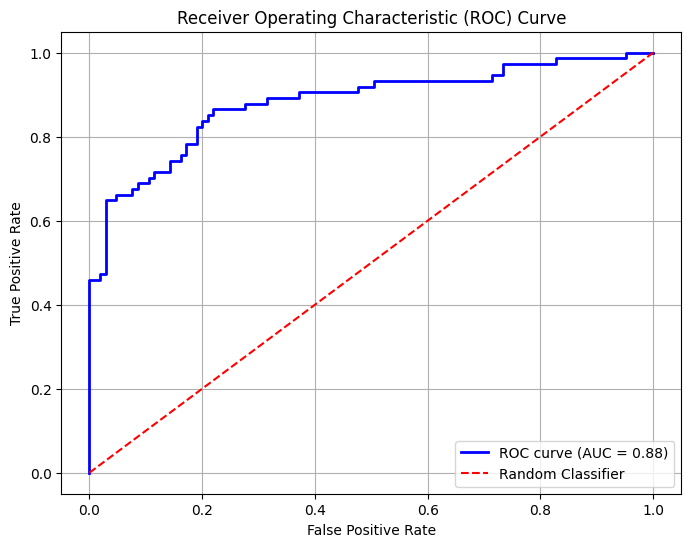

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

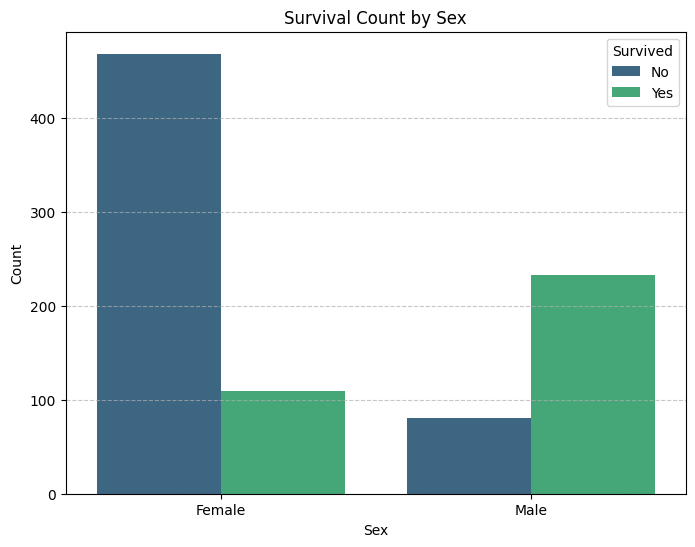

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Sex', hue='Survived', palette='viridis')
plt.title('Survival Count by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male']) # Assuming female is 0 and male is 1 based on one-hot encoding if needed, or just default labels
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()